In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/Iris flower.csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [2]:
# Display basic information about the dataset (data types, non-null counts)
print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [3]:
# Display descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
# Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum())


Missing values per column:


,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


The initial inspection shows that the dataset contains numerical features related to iris flower measurements and a categorical 'species' column. There are no missing values, which simplifies the cleaning process. Next, let's visualize the distribution of each numerical feature using histograms and box plots.

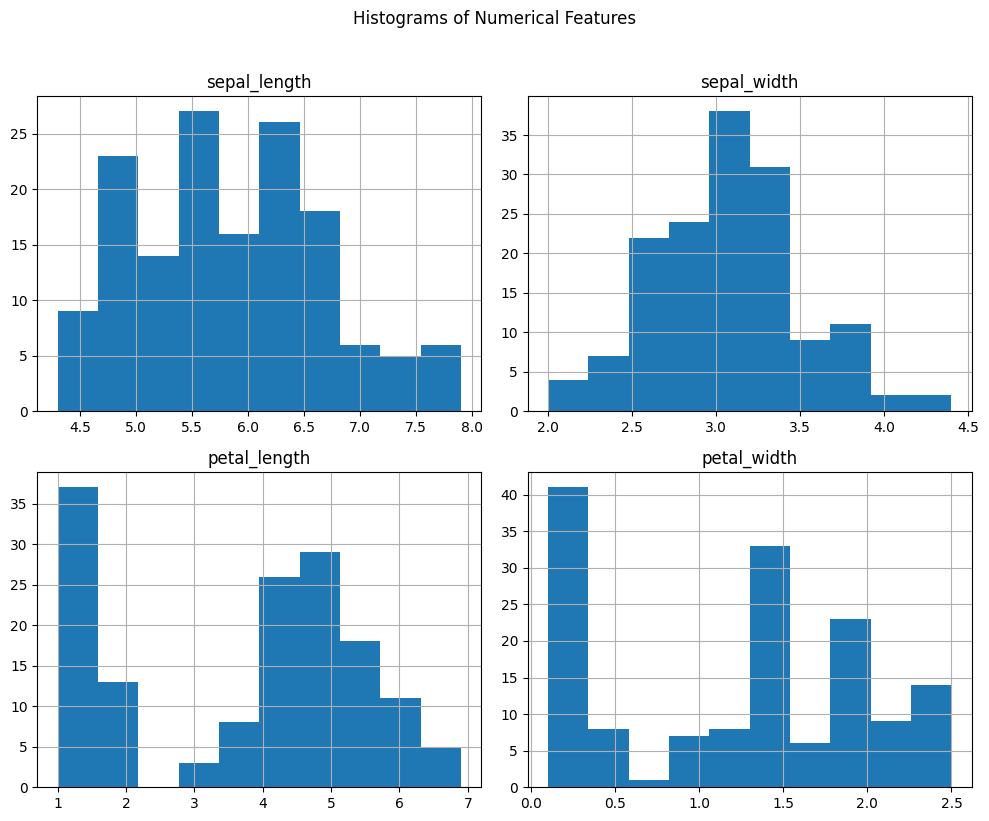

In [5]:
# Visualize the distribution of numerical features using histograms
df.hist(figsize=(10, 8))
plt.suptitle('Histograms of Numerical Features', y=1.02)
plt.tight_layout()
plt.show()

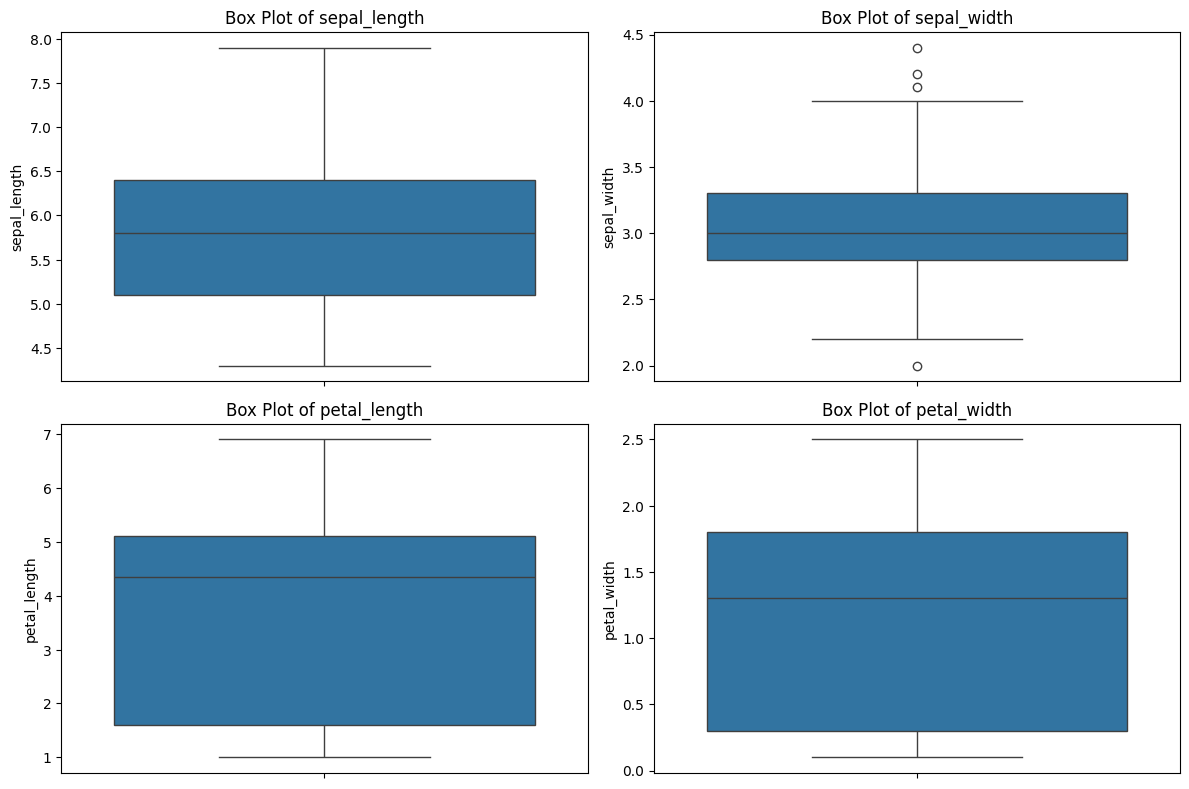

In [6]:
# Visualize distributions and check for outliers using box plots
plt.figure(figsize=(12, 8))
for i, column in enumerate(df.select_dtypes(include=['float64', 'int64']).columns):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=df[column])
    plt.title(f'Box Plot of {column}')
plt.tight_layout()
plt.show()

The histograms show the distribution of each feature, and the box plots help identify potential outliers. Next, I'll visualize the relationships between pairs of features, colored by the 'species' to understand how different iris species separate based on these measurements. A correlation matrix will also provide a quantitative measure of these relationships.

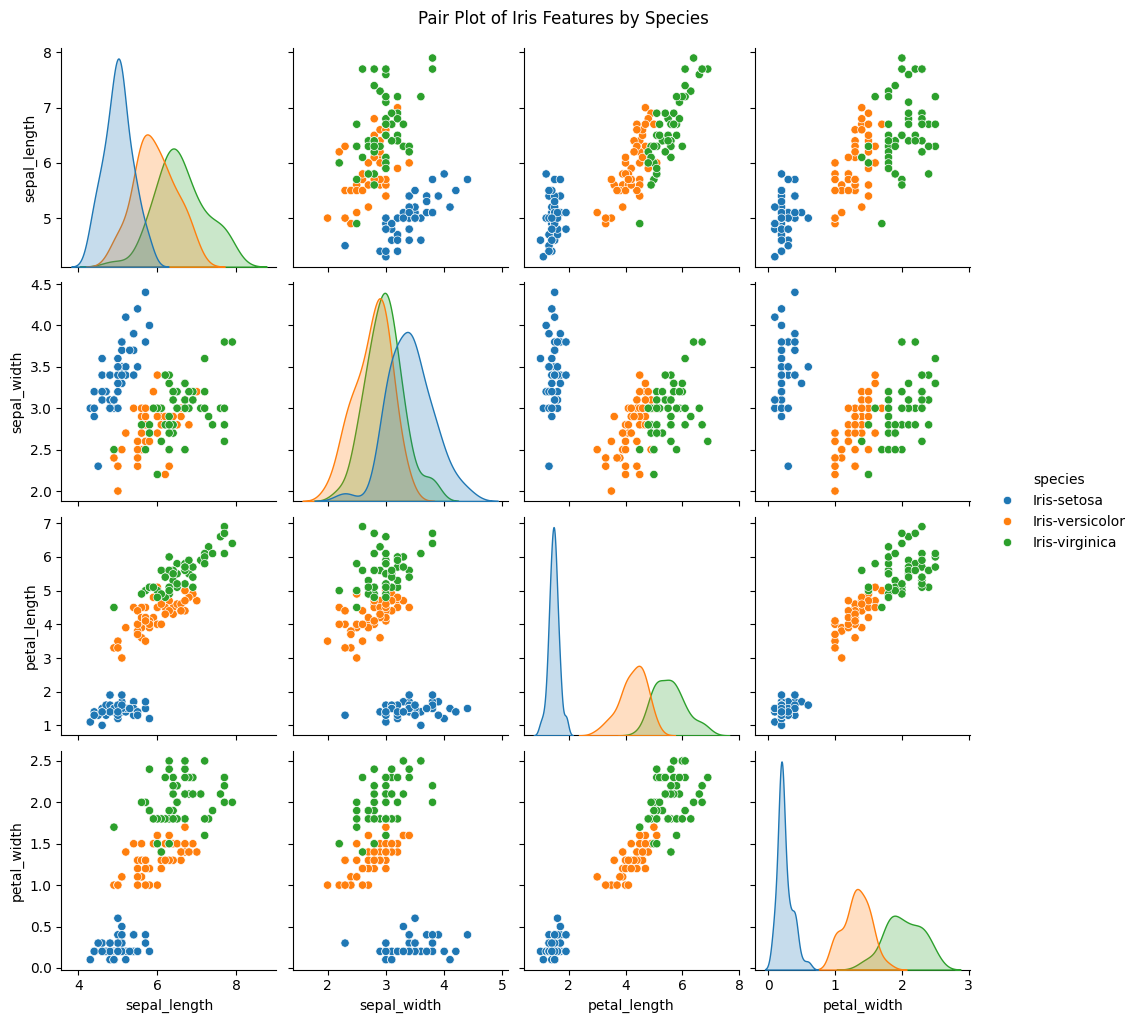

In [7]:
# Visualize relationships between features using a pair plot, colored by 'species'
sns.pairplot(df, hue='species', diag_kind='kde')
plt.suptitle('Pair Plot of Iris Features by Species', y=1.02)
plt.show()

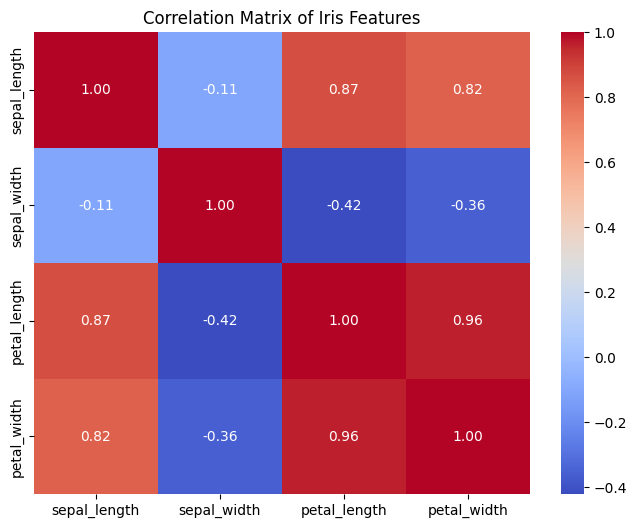

In [8]:
# Calculate and visualize the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Iris Features')
plt.show()

## Decision Tree Model Implementation

Now, let's prepare the data for machine learning. We will define our features (X) and target (y) variables. Since the 'species' column is categorical, we need to convert it into a numerical format using `LabelEncoder`.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Separate features (X) and target (y)
X = df.drop('species', axis=1)
y = df['species']

# Encode the target variable 'species' into numerical labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Original species labels:", le.inverse_transform([0, 1, 2]))
print("Encoded species labels (first 5):")
display(y_encoded[:5])

Original species labels: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Encoded species labels (first 5):


array([0, 0, 0, 0, 0])

Next, we'll split the dataset into training and testing sets. We'll use an 80:20 ratio, meaning 80% of the data will be used for training the model, and the remaining 20% for evaluating its performance. We'll also use `random_state` for reproducibility.

In [10]:
# Split the data into training and testing sets (80:20 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 120 samples
Testing set size: 30 samples


Now, we will train a Decision Tree Classifier on the training data. After training, we'll use the model to make predictions on the test set.

In [11]:
# Initialize the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Train the model on the training data
dt_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_pred = dt_classifier.predict(X_test)

print("First 5 actual labels (encoded):")
display(y_test[:5])
print("First 5 predicted labels (encoded):")
display(y_pred[:5])

First 5 actual labels (encoded):


array([1, 0, 2, 1, 1])

First 5 predicted labels (encoded):


array([1, 0, 2, 1, 1])

## Model Evaluation

Now that the model has made predictions, we need to evaluate its performance. We will calculate the accuracy score and display a classification report, which includes precision, recall, and F1-score for each class.

In [12]:
# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Display the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 1.00

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



## Confusion Matrix and Feature Importance

To further understand the model's performance, let's visualize the Confusion Matrix. This will show us how well the model classified each species. Additionally, we'll generate a bar chart to display the importance of each feature in the Decision Tree model, which can provide insights into which features contributed most to the predictions.

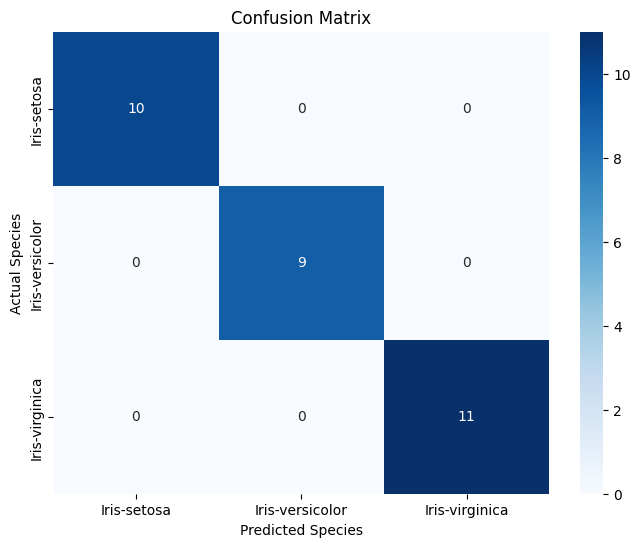

In [13]:
from sklearn.metrics import confusion_matrix

# Generate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the Confusion Matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')
plt.show()

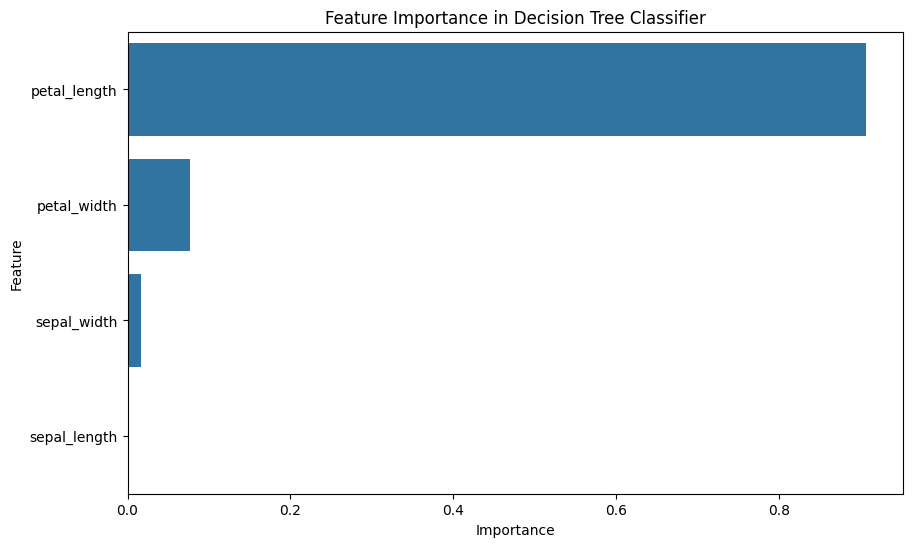

In [14]:
# Get feature importances from the trained Decision Tree classifier
feature_importances = dt_classifier.feature_importances_

# Get feature names from the original DataFrame
feature_names = X.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort features by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance in Decision Tree Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## Decision Tree Visualization

Let's visualize the trained Decision Tree to understand its structure and the decision rules it learned. This graph will show how the model makes predictions based on feature values.

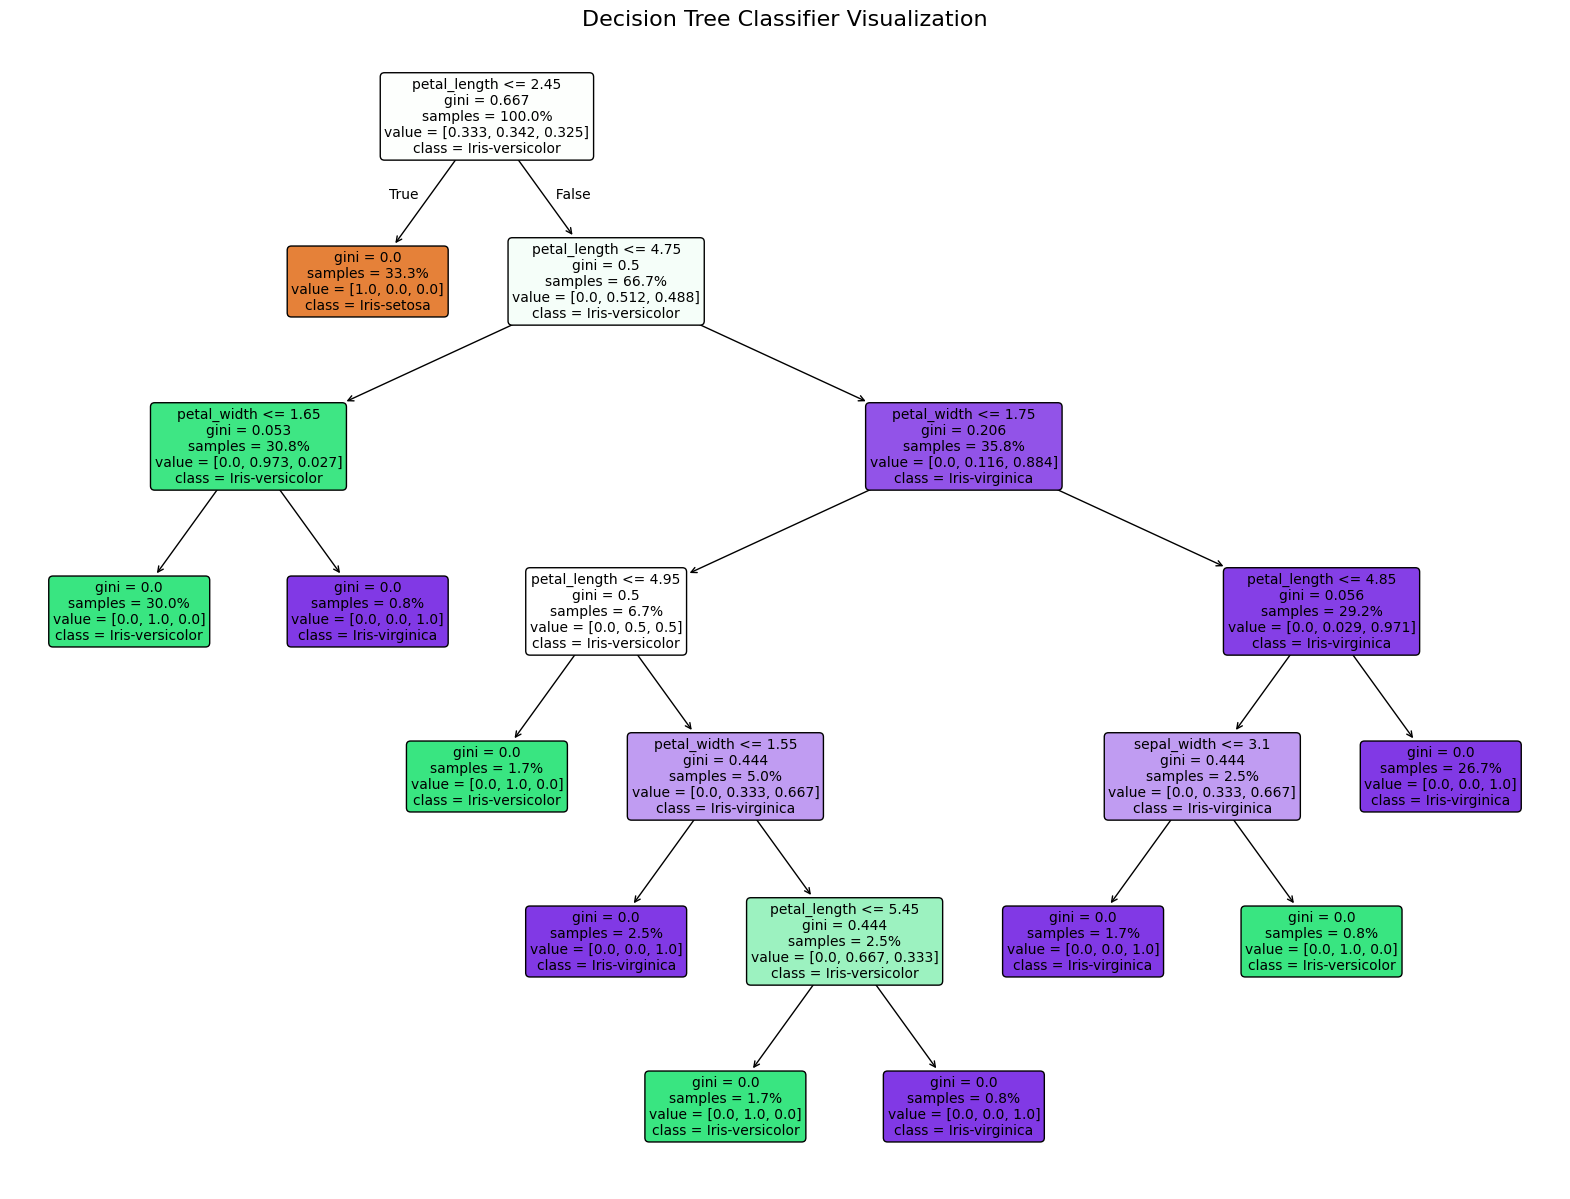

In [15]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 15))
plot_tree(dt_classifier,
          feature_names=X.columns,
          class_names=le.classes_,
          filled=True,
          rounded=True,
          proportion=True,
          fontsize=10)
plt.title('Decision Tree Classifier Visualization', fontsize=16)
plt.show()

## Train, Validation, and Test Split with Accuracy Analysis

To further evaluate the model's generalization capabilities, we will introduce a validation set. We'll split the existing training data (`X_train`, `y_train`) into new training and validation sets. Then we'll retrain the Decision Tree model on the new training set and evaluate its accuracy on the training, validation, and test sets. Finally, we'll visualize these accuracies.

In [16]:
# Split the original training data into new training and validation sets (e.g., 80% train, 20% validation)
X_train_new, X_val, y_train_new, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print(f"New Training set size: {X_train_new.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Test set size (unchanged): {X_test.shape[0]} samples")

New Training set size: 96 samples
Validation set size: 24 samples
Test set size (unchanged): 30 samples


Now, we will retrain the Decision Tree Classifier using the new, smaller training set and then evaluate its performance on all three sets: training, validation, and the original test set.

In [17]:
# Initialize a new Decision Tree Classifier (or re-initialize if using the same variable name)
dt_classifier_re_trained = DecisionTreeClassifier(random_state=42)

# Train the model on the new training data
dt_classifier_re_trained.fit(X_train_new, y_train_new)

# Calculate accuracy on the training, validation, and test sets
train_accuracy = dt_classifier_re_trained.score(X_train_new, y_train_new)
val_accuracy = dt_classifier_re_trained.score(X_val, y_val)
test_accuracy = dt_classifier_re_trained.score(X_test, y_test)

print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Validation Accuracy: {val_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

Training Accuracy: 1.00
Validation Accuracy: 0.92
Test Accuracy: 0.93


Finally, let's visualize these accuracies with a bar chart to easily compare the model's performance across the training, validation, and test datasets. This will serve as our 'train graph', 'validation graph', and 'test graph' in terms of accuracy.

/tmp/ipykernel_1287/1423704607.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Dataset', y='Accuracy', data=accuracy_df, palette='viridis')


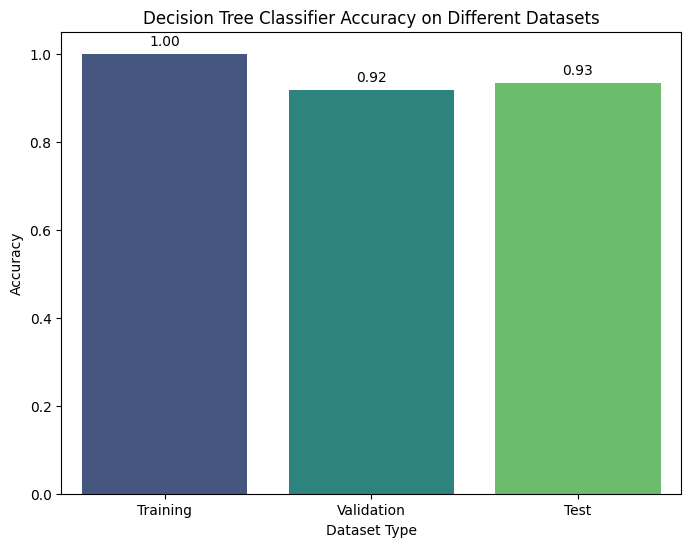

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for visualization
accuracy_df = pd.DataFrame({
    'Dataset': ['Training', 'Validation', 'Test'],
    'Accuracy': [train_accuracy, val_accuracy, test_accuracy]
})

plt.figure(figsize=(8, 6))
sns.barplot(x='Dataset', y='Accuracy', data=accuracy_df, palette='viridis')
plt.ylim(0.0, 1.05) # Set y-axis limit from 0 to 1
plt.title('Decision Tree Classifier Accuracy on Different Datasets')
plt.ylabel('Accuracy')
plt.xlabel('Dataset Type')

# Add accuracy values on top of the bars
for index, row in accuracy_df.iterrows():
    plt.text(index, row['Accuracy'] + 0.02, f'{row['Accuracy']:.2f}', color='black', ha="center")

plt.show()

### Learning Curve

Now, let's create a learning curve. This plot helps us understand how the model's performance improves with more training data and whether it's suffering from high bias or high variance. We'll use cross-validation to assess the model consistently.

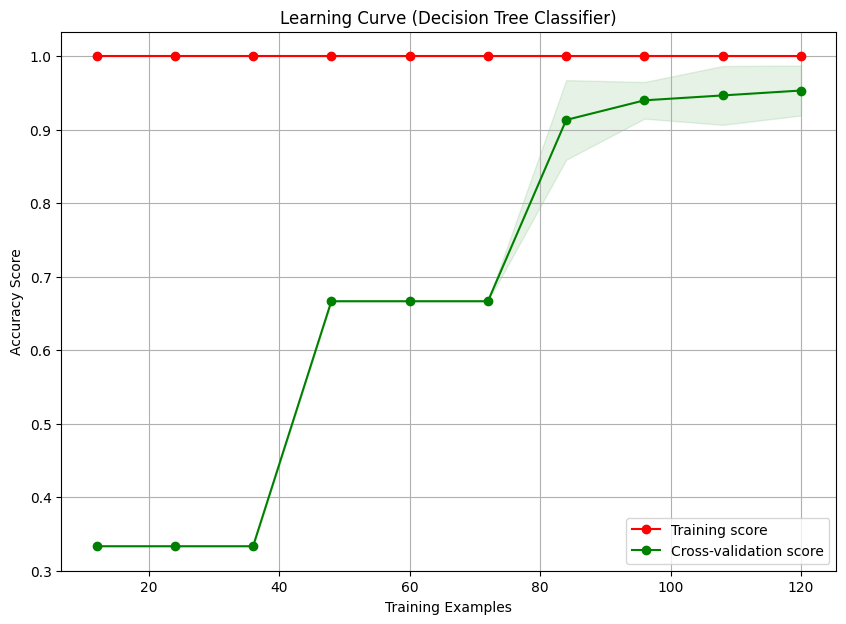

In [20]:
import numpy as np
from sklearn.model_selection import learning_curve, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns

# Define the model and parameters for the learning curve
estimator = DecisionTreeClassifier(random_state=42)
train_sizes, train_scores, test_scores = learning_curve(
    estimator, X, y_encoded, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
)

# Calculate mean and standard deviation for training and test scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 7))
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1,
                 color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
         label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
         label="Cross-validation score")

plt.title('Learning Curve (Decision Tree Classifier)')
plt.xlabel('Training Examples')
plt.ylabel('Accuracy Score')
plt.legend(loc="best")
plt.grid(True)
plt.show()

## Addressing Overfitting with Pruning and Cross-Validation

The previous Decision Tree model showed signs of overfitting (100% training accuracy vs. 93% test accuracy). To mitigate this, we will use **pruning techniques** and **cross-validation**.

*   **Pruning**: We will limit the tree's complexity using hyperparameters like `max_depth` (maximum depth of the tree) and `min_samples_leaf` (minimum number of samples required to be at a leaf node). This prevents the tree from growing too deep and capturing noise in the training data.
*   **Cross-Validation**: We'll use `GridSearchCV` with cross-validation to systematically search for the best combination of `max_depth` and `min_samples_leaf` that provides the best generalization performance, rather than just relying on a single train-test split.

In [21]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Define the parameter grid for pruning
param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 7, 8, 9, 10, None], # None means no limit
    'min_samples_leaf': [1, 2, 3, 4, 5, 10]
}

# Initialize a Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV
# We'll use the original X_train and y_train for grid search to find the best parameters
# The best parameters will then be applied to train the final model.
grid_search = GridSearchCV(estimator=dtc, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: ", grid_search.best_score_)

# Get the best estimator (the pruned model)
best_dt_classifier = grid_search.best_estimator_

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best parameters found:  {'max_depth': 3, 'min_samples_leaf': 3}
Best cross-validation accuracy:  0.95


### Evaluation of the Pruned Decision Tree Model

Now, let's evaluate the performance of the pruned Decision Tree model on both the training and test sets and compare it to the previous model.

Pruned Model Training Accuracy: 0.95
Pruned Model Testing Accuracy: 1.00

--- Comparison with previous model ---
Previous Model Training Accuracy: 1.00
Previous Model Testing Accuracy: 0.93


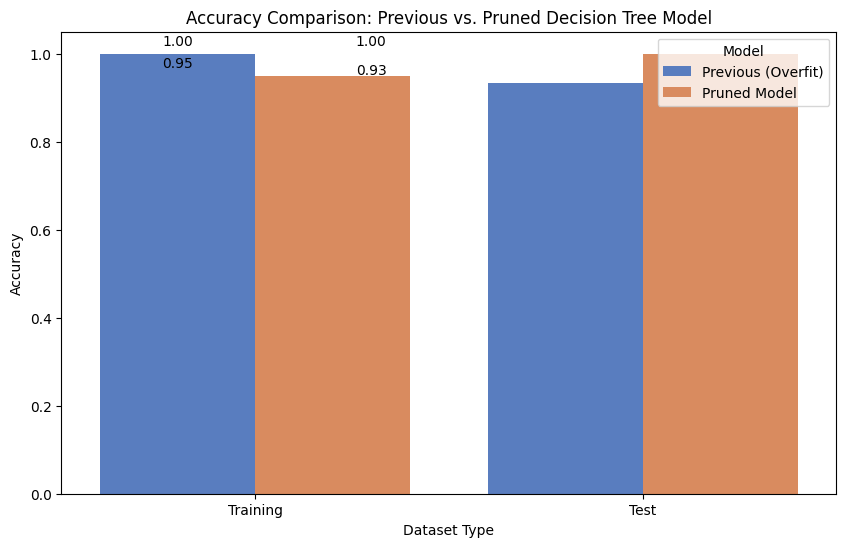

In [22]:
# Calculate accuracy on the training and test sets using the best pruned model
pruned_train_accuracy = best_dt_classifier.score(X_train, y_train)
pruned_test_accuracy = best_dt_classifier.score(X_test, y_test)

print(f"Pruned Model Training Accuracy: {pruned_train_accuracy:.2f}")
print(f"Pruned Model Testing Accuracy: {pruned_test_accuracy:.2f}")

print("\n--- Comparison with previous model ---")
print(f"Previous Model Training Accuracy: {train_accuracy:.2f}") # Using train_accuracy from earlier step (1.00)
print(f"Previous Model Testing Accuracy: {test_accuracy:.2f}")   # Using test_accuracy from earlier step (0.93)

# Create a DataFrame for visualization of accuracies
comparison_df = pd.DataFrame({
    'Model': ['Previous (Overfit)', 'Previous (Overfit)', 'Pruned Model', 'Pruned Model'],
    'Dataset': ['Training', 'Test', 'Training', 'Test'],
    'Accuracy': [train_accuracy, test_accuracy, pruned_train_accuracy, pruned_test_accuracy]
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Dataset', y='Accuracy', hue='Model', data=comparison_df, palette='muted')
plt.ylim(0.0, 1.05)
plt.title('Accuracy Comparison: Previous vs. Pruned Decision Tree Model')
plt.ylabel('Accuracy')
plt.xlabel('Dataset Type')

# Add accuracy values on top of the bars
for index, row in comparison_df.iterrows():
    plt.text(index % 2 * (1/2) - 0.2, row['Accuracy'] + 0.02, f'{row['Accuracy']:.2f}', color='black', ha="center")

plt.show()

### Visualizing the Pruned Decision Tree

Finally, let's visualize the structure of the Decision Tree after pruning. You will observe that this tree is much simpler and less deep compared to the unpruned version, which helps in preventing overfitting.

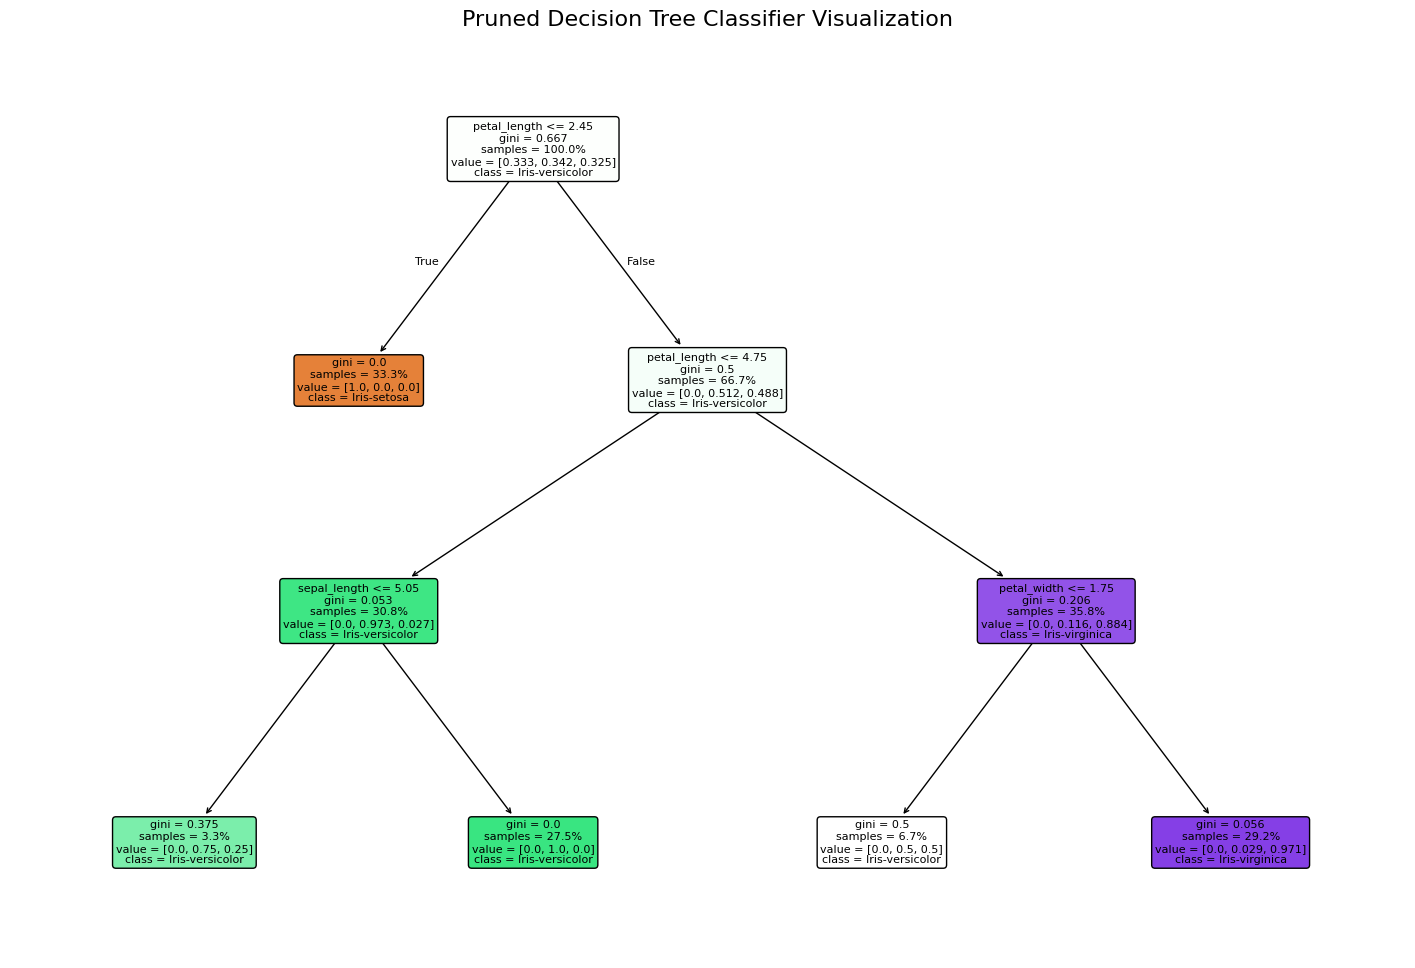

In [23]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 12)) # Adjust figure size for better readability of a smaller tree
plot_tree(best_dt_classifier,
          feature_names=X.columns,
          class_names=le.classes_,
          filled=True,
          rounded=True,
          proportion=True,
          fontsize=8)
plt.title('Pruned Decision Tree Classifier Visualization', fontsize=16)
plt.show()

In [24]:
print("Predictions for the unpruned model (y_pred):")
display(y_pred)
print(f"Accuracy of the unpruned model: {accuracy:.2f}")

Predictions for the unpruned model (y_pred):


array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

Accuracy of the unpruned model: 1.00


## Overall Accuracy and Classification Report for the Pruned Model

Let's display the overall test accuracy and the detailed classification report for the pruned Decision Tree model, which showed improved generalization.

In [25]:
from sklearn.metrics import classification_report

# Make predictions with the best (pruned) model on the test data
y_pred_pruned = best_dt_classifier.predict(X_test)

# Display the overall test accuracy (already calculated as pruned_test_accuracy)
print(f"Overall Test Accuracy (Pruned Model): {pruned_test_accuracy:.2f}")

# Display the classification report for the pruned model
print("\nClassification Report (Pruned Model):")
print(classification_report(y_test, y_pred_pruned, target_names=le.classes_))

Overall Test Accuracy (Pruned Model): 1.00

Classification Report (Pruned Model):
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



### Confusion Matrix for the Pruned Model

To further visualize the performance of the pruned model, let's create a confusion matrix. This will show us how many instances of each class were correctly and incorrectly classified by the `best_dt_classifier`.

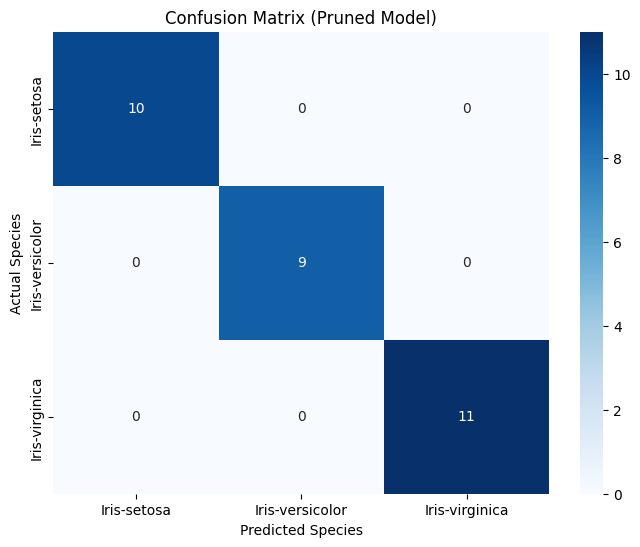

In [26]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the Confusion Matrix for the pruned model
cm_pruned = confusion_matrix(y_test, y_pred_pruned)

# Plot the Confusion Matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_pruned, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix (Pruned Model)')
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')
plt.show()

## Save the Pruned Decision Tree Model

Now that we have a well-performing, pruned Decision Tree model, we can save it to a file for future use. This prevents the need to retrain the model every time we want to make predictions or analyze its structure. We'll use `joblib` for this, which is efficient for saving `scikit-learn` models.

In [27]:
import joblib

# Define the filename for the saved model
model_filename = 'pruned_decision_tree_model.joblib'

# Save the best_dt_classifier model
joblib.dump(best_dt_classifier, model_filename)

print(f"Pruned Decision Tree model saved successfully as '{model_filename}'")

Pruned Decision Tree model saved successfully as 'pruned_decision_tree_model.joblib'
